# Figure 1- Panel A

### Load Difficulty Result

In [ ]:
d_viz_target = input("INPUT 'visualization_target for difficulty RUN_ID'(e.g., run_id_1): ")
c_viz_target = input("INPUT 'visualization_target for complexity RUN_ID'(e.g., run_id_20000): ")

print(f'Figure will be drawn based on the {d_viz_target} and {c_viz_target} dataset')

Figure will be drawn based on the run_id_1 and run_id_20000 dataset


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting

import lib.annotation.tools.Result_Prep as rp

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
import lib.visualization.plot_generator_bak as PlotGen
import lib.visualization.figure_setting as figure_setting

mpl.rcParams.update(figure_setting.fig_setting)




In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/annotate_difficulty/{d_viz_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'

In [4]:
path = f"{viz_dir}/{option_dict['operation_option']['llm_model']}"
file_list = os.listdir(path)
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=50000) & (int(y)<160000)])


In [5]:
r_p = rp.Result_Prep()
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        df = r_p.pp_df(df, 5)
        df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [6]:
src_dir = f'{path_list["data_root_dir"]}/result/code_complexity/cyclomatic_complexity/{c_viz_target}'

option_dict = load_json(f"{src_dir}/data/option.json")
std_date = Date_Setting[option_dict['year_range']]['std_date']

origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])

df = read_complexity_jsonl(option_dict)
# df = calculate_cyclomatic_complexity(df, "sum")
df['cyclomatic_complexity'] = np.log(df['cyclomatic_complexity']+1)

viz_df = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'cyclomatic_complexity']]
viz_df['rel_week'] = np.floor((pd.to_datetime(viz_df['creationdate'], format='mixed')- std_date).dt.days/7)
viz_df = (viz_df.groupby('rel_week', as_index=False)['cyclomatic_complexity'].mean())


100%|██████████| 65/65 [00:19<00:00,  3.26it/s]


In [7]:
def draw_complexity_regression(ax, x, y, st_chow,
                               F_stat_1, p_value_1, title,
                               panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1
    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # ── 산점도 
    ax.scatter(x, y, s=3, color=figure_setting.PALETTE['point'],
               alpha=0.55, lw=0, zorder=2, clip_on=False)

    # ── Overall fit 
    ax.plot(x, st_chow.y_predict,
            color=figure_setting.PALETTE['neutral'], lw=0.9, ls='--',
            alpha=0.65, zorder=3, label='Overall fit')

    # ── Before ChatGPT
    ax.fill_between(
        x1,
        st_chow.y1_predict - st_chow.y1_conf_interval,
        st_chow.y1_predict + st_chow.y1_conf_interval,
        color=figure_setting.PALETTE['primary'], alpha=0.25, lw=0, zorder=4)
    
    ax.plot(x1, st_chow.y1_predict,
            color=figure_setting.PALETTE['primary'], lw=2.0, zorder=5,
            label='Before ChatGPT')

    # ── After ChatGPT
    ax.fill_between(
        x2,
        st_chow.y2_predict - st_chow.y2_conf_interval,
        st_chow.y2_predict + st_chow.y2_conf_interval,
        color=figure_setting.PALETTE['accent'], alpha=0.25, lw=0, zorder=4)
    ax.plot(x2, st_chow.y2_predict,
            color=figure_setting.PALETTE['accent'], lw=2.0, zorder=5,
            label='After ChatGPT')

    # ── virtical line for chatGPT release
    ax.axvline(x=0, color=figure_setting.PALETTE['event'],
               linestyle='--', linewidth=0.9, zorder=1)

    # ── set title with p-value
    p_txt = '$p$ < 0.001' if p_value_1 < 0.001 else f'$p$ = {p_value_1:.3f}'
    prefix = f'{panel_label}.  ' if panel_label else ''
    ax.set_title(
        f'{prefix} {title}  ({p_txt})',
        fontsize=figure_setting.FONT['title'], loc='left', pad=10, color='#222',
        fontweight='normal'
    )


    
    # ── ticks
    ax.tick_params(axis='both', labelsize=9.5,
                   width=0.8, length=3, pad=2)

    # ── Spine 
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.spines['left'].set_linewidth(0.9)
    ax.spines['bottom'].set_linewidth(0.9)
    ax.spines['left'].set_position(('outward', 3))
    ax.spines['bottom'].set_position(('outward', 3))

    # ── remove grid 
    ax.grid(False)

    # ── set x lim
    ax.set_xlim(x.min(), x.max())
    ax.margins(x=0.02, y=0.05)

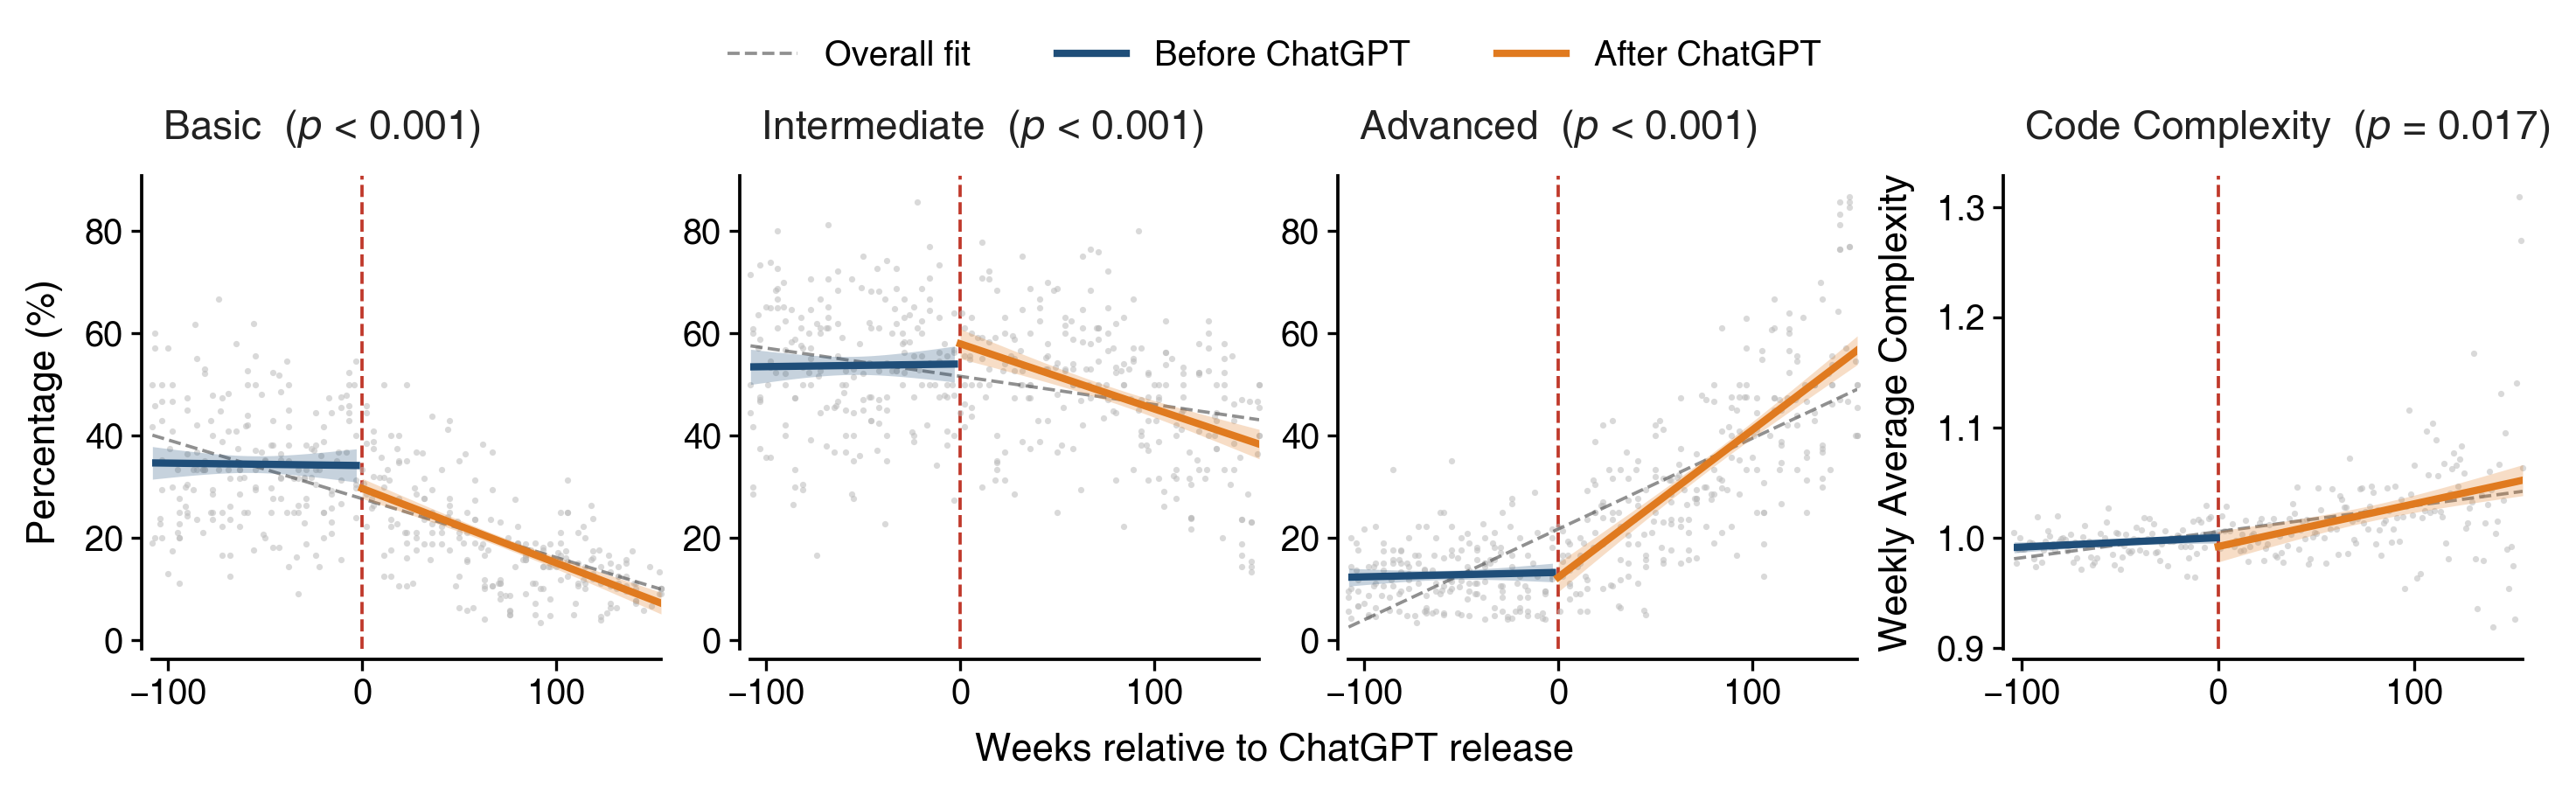

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(9.6, 2.6), constrained_layout=True,  dpi=300)
label_dict = {'A' : 'Basic', 'B' : 'Intermediate', 'C':'Advanced'}

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = tot_calc[tot_calc['o_result'] == str(i)].sort_values(by = ['rel_week'], ascending=True).reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    F_stat, p_value = st_chow.chow_test()
    draw_complexity_regression(
        axes[i],
        x,
        y,
        st_chow,
        F_stat,
        p_value,
        title=f"{title}",
        panel_label=""
    )
y_min = min(ax.get_ylim()[0] for ax in axes[:3])
y_max = max(ax.get_ylim()[1] for ax in axes[:3])
for ax in axes[:3]:
    ax.set_ylim(y_min, y_max)


chk_cnt = viz_df.sort_values(by = ['rel_week'], ascending=True).reset_index(drop=True)
x = chk_cnt['rel_week'].values
y = chk_cnt['cyclomatic_complexity'].values

st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
F_stat, p_value = st_chow.chow_test()
draw_complexity_regression(
    axes[-1],
    x,
    y,
    st_chow,
    F_stat,
    p_value,
    title=f"Code Complexity",
    panel_label=""
)



fig.supxlabel("Weeks relative to ChatGPT release",
                fontsize=figure_setting.FONT['label'])
axes[0].set_ylabel("Percentage (%)",
                fontsize=figure_setting.FONT['label'], labelpad=6)
axes[-1].set_ylabel("Weekly Average Complexity",
                fontsize=figure_setting.FONT['label'], labelpad=6)
        

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=3, frameon=False, fontsize=figure_setting.FONT['legend'],
    handlelength=2.0, columnspacing=2.5
)

plt.show()

2.4

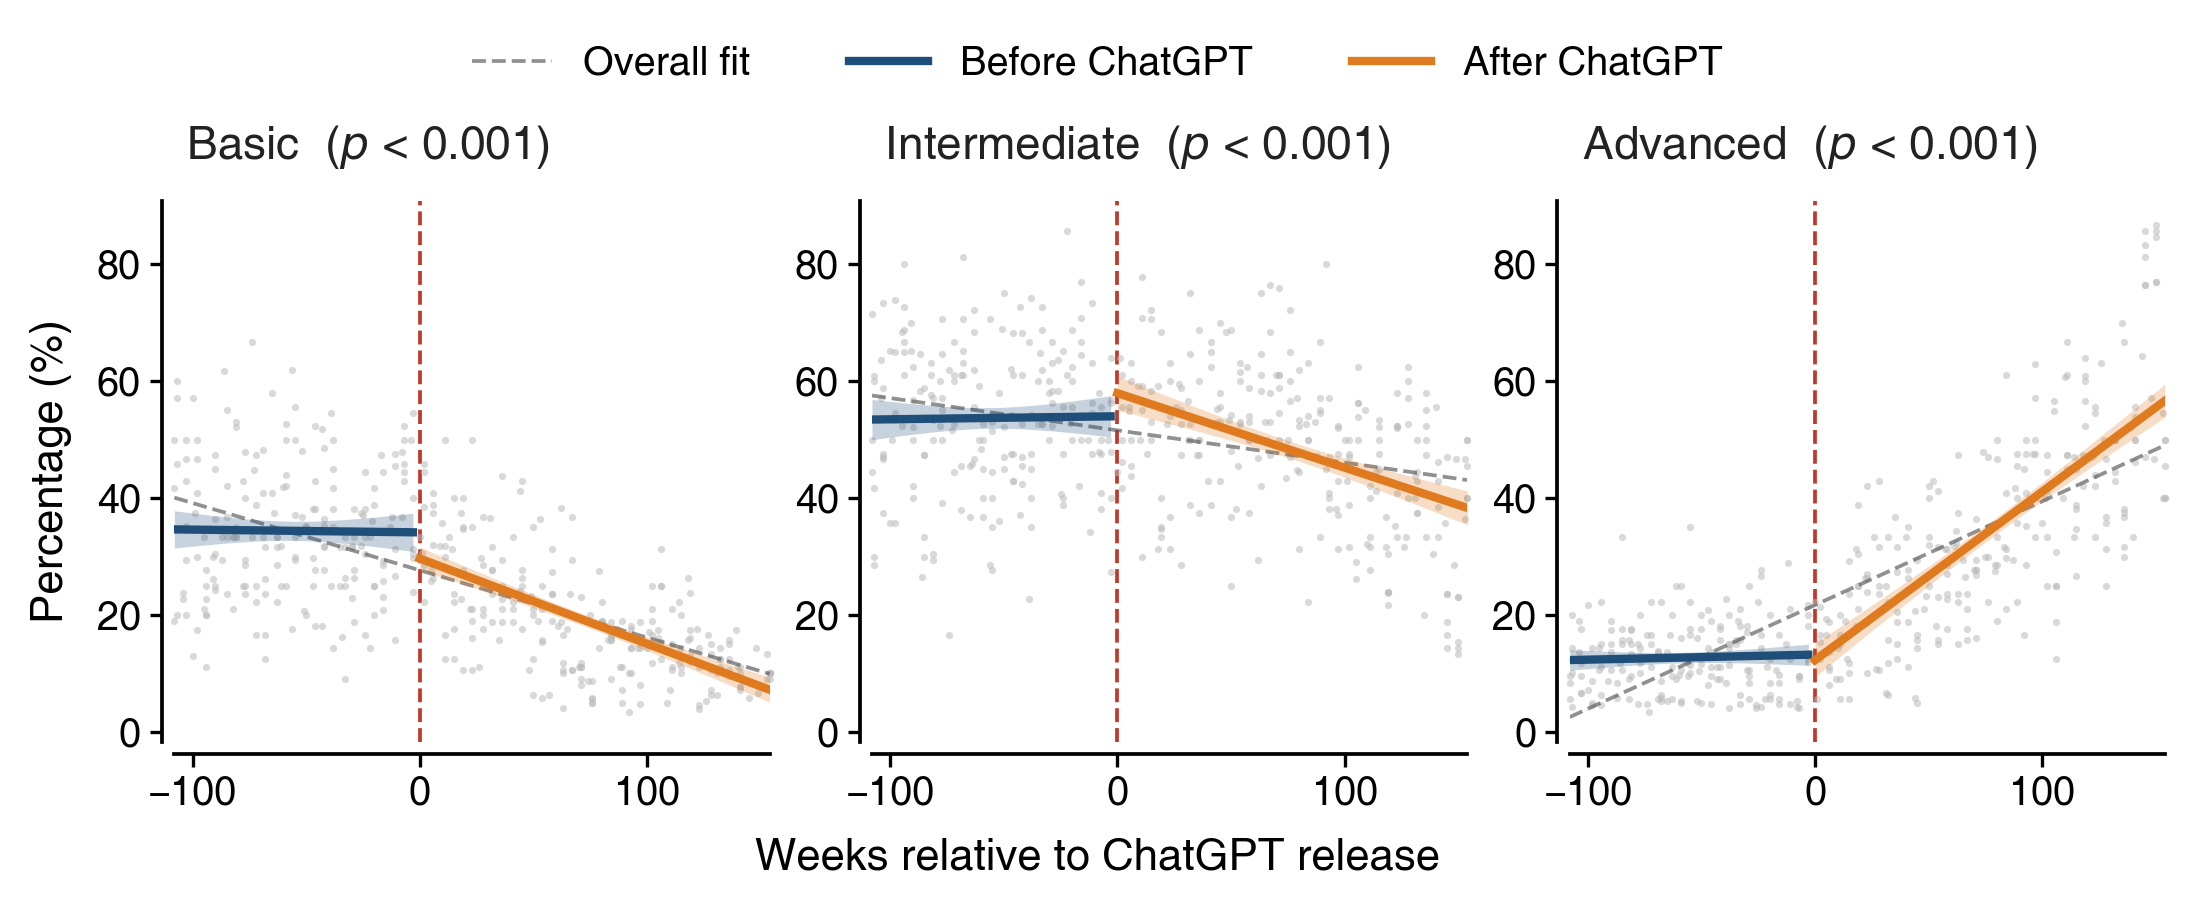

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(figure_setting.FIG_SIZE['x']*3, figure_setting.FIG_SIZE['y']), constrained_layout=True,  dpi=300)
label_dict = {'A' : 'Basic', 'B' : 'Intermediate', 'C':'Advanced'}

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = tot_calc[tot_calc['o_result'] == str(i)].sort_values(by = ['rel_week'], ascending=True).reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    F_stat, p_value = st_chow.chow_test()
    draw_complexity_regression(
        axes[i],
        x,
        y,
        st_chow,
        F_stat,
        p_value,
        title=f"{title}",
        panel_label=""
    )
y_min = min(ax.get_ylim()[0] for ax in axes[:3])
y_max = max(ax.get_ylim()[1] for ax in axes[:3])
for ax in axes[:3]:
    ax.set_ylim(y_min, y_max)



fig.supxlabel("Weeks relative to ChatGPT release",
                fontsize=figure_setting.FONT['label'])
axes[0].set_ylabel("Percentage (%)",
                fontsize=figure_setting.FONT['label'], labelpad=6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=3, frameon=False, fontsize=figure_setting.FONT['legend'],
    handlelength=2.0, columnspacing=2.5
)

plt.show()

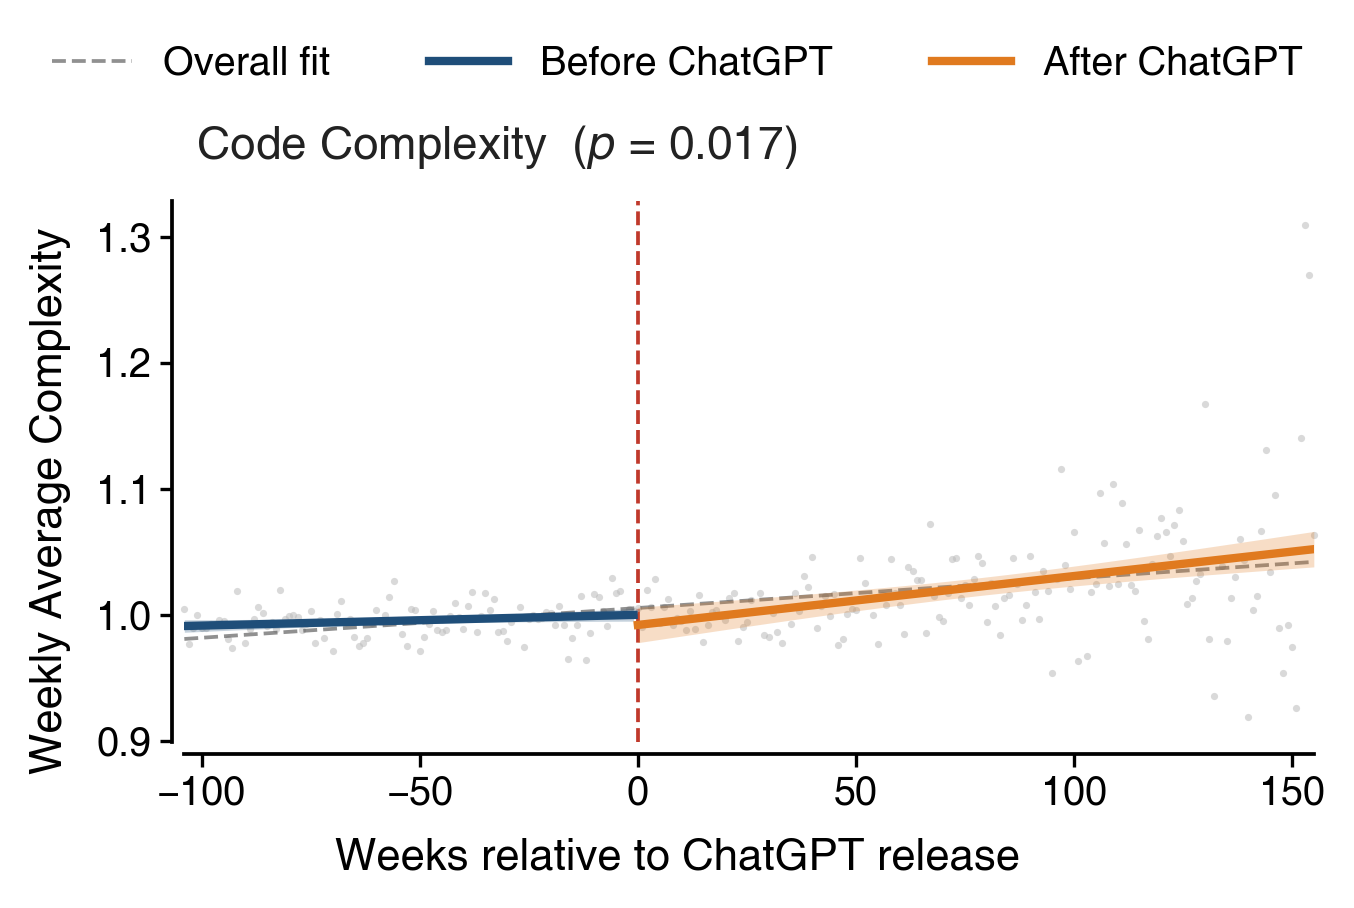

In [15]:
fig, axes = plt.subplots(1, 1, figsize=(figure_setting.FIG_SIZE['x']+2, figure_setting.FIG_SIZE['y']), constrained_layout=True,  dpi=300)
label_dict = {'A' : 'Basic', 'B' : 'Intermediate', 'C':'Advanced'}


    
chk_cnt = viz_df.sort_values(by = ['rel_week'], ascending=True).reset_index(drop=True)
x = chk_cnt['rel_week'].values
y = chk_cnt['cyclomatic_complexity'].values

st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
F_stat, p_value = st_chow.chow_test()
draw_complexity_regression(
    axes,
    x,
    y,
    st_chow,
    F_stat,
    p_value,
    title=f"Code Complexity",
    panel_label=""
)



fig.supxlabel("Weeks relative to ChatGPT release",
                fontsize=figure_setting.FONT['label'])
fig.supylabel("Weekly Average Complexity",
                fontsize=figure_setting.FONT['label'])
        

handles, labels = axes.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=3, frameon=False, fontsize=figure_setting.FONT['legend'],
    handlelength=2.0, columnspacing=2.5
)


plt.show()